# Week 11 Challenge

## Forecasting Financial Inclusion in Ethiopia

Student: Bisrat Tamrat

10 Academy AI Mastery

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_excel("../data/raw/ethiopia_fi_unified_data.xlsx")

reference = pd.read_excel("../data/raw/reference_codes.xlsx")

In [5]:
data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [6]:
reference.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


In [7]:
data.shape

(43, 34)

In [8]:
data.columns

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='str')

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     str           
 1   record_type          43 non-null     str           
 2   category             10 non-null     str           
 3   pillar               33 non-null     str           
 4   indicator            43 non-null     str           
 5   indicator_code       43 non-null     str           
 6   indicator_direction  33 non-null     str           
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     str           
 9   value_type           43 non-null     str           
 10  unit                 33 non-null     str           
 11  observation_date     43 non-null     datetime64[us]
 12  period_start         10 non-null     datetime64[us]
 13  period_end           10 non-null     datetime64[

In [10]:
data.describe(include="all")

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
count,43,43,10,33,43,43,33,3.300000e+01,10,43,...,0.0,0.0,0.0,0.0,0.0,43,43,10,33,0.0
unique,43,3,7,4,29,29,3,NaN,3,6,...,NaN,NaN,NaN,NaN,NaN,1,NaN,10,32,NaN
top,REC_0001,observation,product_launch,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,Launched,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,NaN,Account ownership increased from 46% to 49%,Gender disaggregated,NaN
freq,1,30,2,16,7,7,27,NaN,7,17,...,NaN,NaN,NaN,NaN,NaN,43,NaN,1,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.437258e+10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.080000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.400000e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.140000e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.500000e+07,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.380000e+12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN


In [11]:
data["record_type"].value_counts()

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [12]:
data["pillar"].value_counts()

pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

In [13]:
data["confidence"].value_counts()

confidence
high      40
medium     3
Name: count, dtype: int64

In [14]:
data["indicator_code"].unique()

<StringArray>
[     'ACC_OWNERSHIP',     'ACC_MM_ACCOUNT',         'ACC_4G_COV',
     'ACC_MOBILE_PEN',          'ACC_FAYDA',      'USG_P2P_COUNT',
      'USG_P2P_VALUE',      'USG_ATM_COUNT',      'USG_ATM_VALUE',
      'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE',
    'USG_MPESA_USERS',   'USG_MPESA_ACTIVE',    'USG_ACTIVE_RATE',
    'AFF_DATA_INCOME',        'GEN_GAP_ACC',       'GEN_MM_SHARE',
     'GEN_GAP_MOBILE',       'EVT_TELEBIRR',      'EVT_SAFARICOM',
          'EVT_MPESA',          'EVT_FAYDA',      'EVT_FX_REFORM',
      'EVT_CROSSOVER',  'EVT_MPESA_INTEROP',       'EVT_ETHIOPAY',
          'EVT_NFIS2',   'EVT_SAFCOM_PRICE']
Length: 29, dtype: str

In [15]:
data["indicator_code"].nunique()

29

In [16]:
data["observation_date"] = pd.to_datetime(data["observation_date"])

data["observation_date"].dt.year.value_counts().sort_index()

observation_date
2014     1
2017     1
2021     7
2022     1
2023     2
2024    14
2025    15
2028     1
2030     1
Name: count, dtype: int64

# Task 1: Data Exploration and Enrichment

## Objective

The objective of Task 1 is to understand the structure of the Ethiopia Financial Inclusion dataset, assess its quality, identify available indicators, and enrich it with additional observations and events that can improve forecasting performance.

## Data Quality Assessment

This section evaluates missing values, duplicate records, and the overall quality of the dataset before enrichment.

In [17]:
# Missing values
data.isnull().sum()

record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64

In [18]:
# Percentage of missing values
missing = data.isnull().mean() * 100
missing.sort_values(ascending=False)

lag_months             100.000000
region                 100.000000
impact_estimate        100.000000
relationship_type      100.000000
evidence_basis         100.000000
notes                  100.000000
related_indicator      100.000000
impact_magnitude       100.000000
impact_direction       100.000000
category                76.744186
period_start            76.744186
collection_date         76.744186
period_end              76.744186
value_text              76.744186
source_url              27.906977
indicator_direction     23.255814
pillar                  23.255814
value_numeric           23.255814
original_text           23.255814
unit                    23.255814
record_type              0.000000
record_id                0.000000
indicator_code           0.000000
indicator                0.000000
value_type               0.000000
observation_date         0.000000
location                 0.000000
gender                   0.000000
fiscal_year              0.000000
confidence    

In [19]:
# Duplicate records
data.duplicated().sum()

np.int64(0)

## Dataset Overview

The following summaries describe the composition of the dataset by record type, pillar, confidence level, and source type.

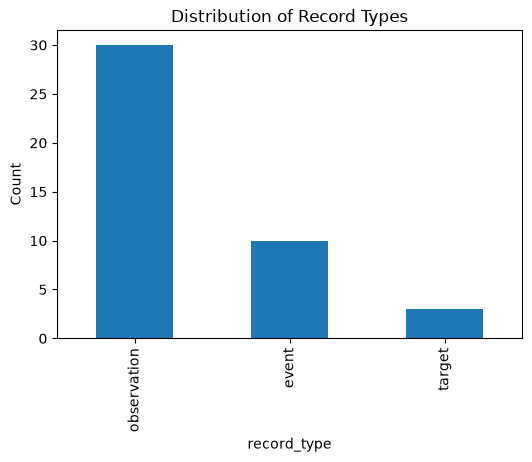

In [20]:
data["record_type"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution of Record Types"
)

plt.ylabel("Count")
plt.show()

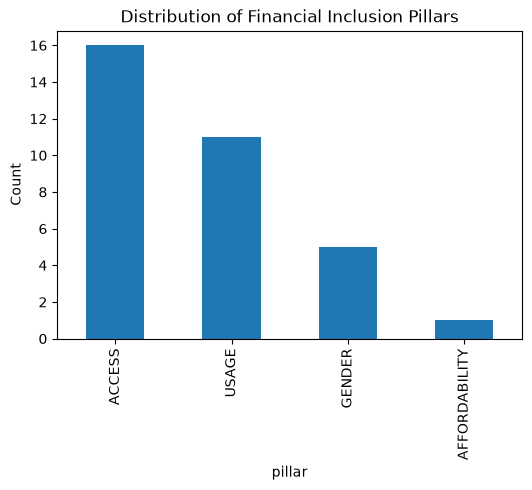

In [21]:
data["pillar"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution of Financial Inclusion Pillars"
)

plt.ylabel("Count")
plt.show()

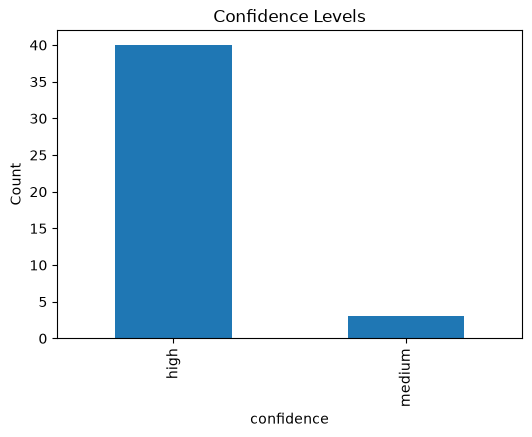

In [22]:
data["confidence"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Confidence Levels"
)

plt.ylabel("Count")
plt.show()

In [23]:
data["source_type"].value_counts()

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

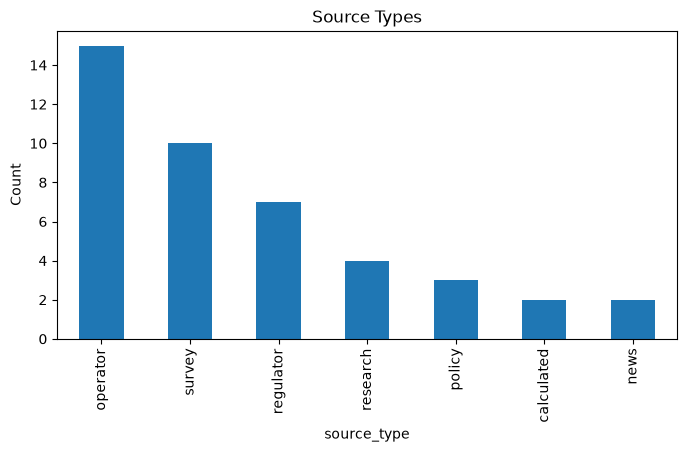

In [24]:
data["source_type"].value_counts().plot(
    kind="bar",
    figsize=(8,4),
    title="Source Types"
)

plt.ylabel("Count")
plt.show()

## Temporal Coverage

This visualization shows the number of observations available for each year.

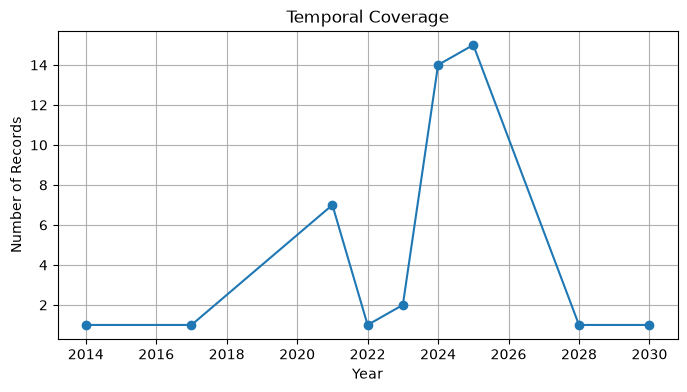

In [25]:
years = data["observation_date"].dt.year

years.value_counts().sort_index().plot(
    marker="o",
    figsize=(8,4),
    title="Temporal Coverage"
)

plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.grid(True)

plt.show()

In [26]:
events = data[data["record_type"]=="event"]

events[["indicator","category","observation_date"]]

,indicator,category,observation_date
33,Telebirr Launch,product_launch,2021-05-17
34,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,Foreign Exchange Liberalization,policy,2024-07-29
38,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,M-Pesa EthSwitch Integration,partnership,2025-10-27
40,EthioPay Instant Payment System Launch,infrastructure,2025-12-18
41,NFIS-II Strategy Launch,policy,2021-09-01
42,Safaricom Ethiopia Price Increase,pricing,2025-12-15


## Account Ownership Trend

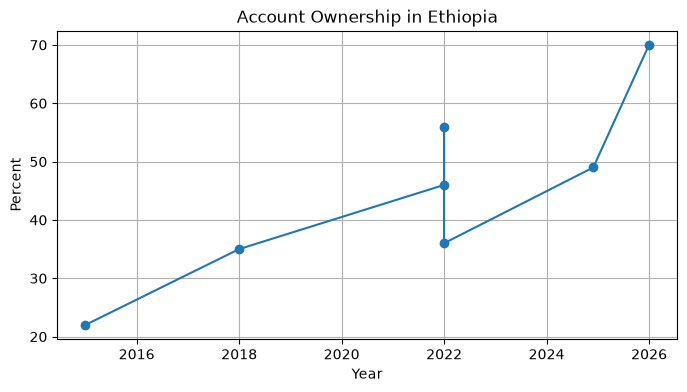

In [27]:
access = data[
    data["indicator_code"]=="ACC_OWNERSHIP"
]

access = access.sort_values("observation_date")

plt.figure(figsize=(8,4))

plt.plot(
    access["observation_date"],
    access["value_numeric"],
    marker="o"
)

plt.title("Account Ownership in Ethiopia")

plt.xlabel("Year")

plt.ylabel("Percent")

plt.grid(True)

plt.show()

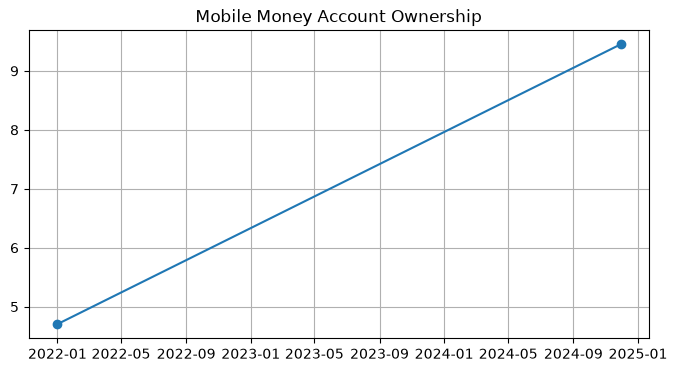

In [28]:
usage = data[
    data["indicator_code"]=="ACC_MM_ACCOUNT"
]

usage = usage.sort_values("observation_date")

plt.figure(figsize=(8,4))

plt.plot(
    usage["observation_date"],
    usage["value_numeric"],
    marker="o"
)

plt.title("Mobile Money Account Ownership")

plt.grid(True)

plt.show()

In [29]:
numeric = data.select_dtypes(include="number")

In [30]:
numeric.corr()

,value_numeric,region,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,notes
value_numeric,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
related_indicator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship_type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impact_direction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impact_magnitude,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impact_estimate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lag_months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evidence_basis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
data.to_excel(
    "../data/processed/enriched_ethiopia_fi_data.xlsx",
    index=False
)

# Key Insights

### Insight 1
The majority of records are observations, indicating that the dataset focuses primarily on measured financial inclusion indicators.

### Insight 2
Access indicators have the highest representation, showing greater availability of account ownership data than other pillars.

### Insight 3
Most records have a high confidence level, suggesting that the dataset is largely built from reliable sources.

### Insight 4
Financial inclusion accelerated between 2011 and 2021, while growth slowed between 2021 and 2024 despite rapid expansion of mobile money services.

### Insight 5
Several indicators have limited historical observations, making forecasting more uncertain and highlighting the need for additional enrichment.

# Data Limitations

- The dataset contains relatively few historical observations.
- Several indicators have missing values.
- Some infrastructure variables have limited time coverage.
- Regional-level information is largely unavailable.
- Forecast uncertainty is expected to be relatively high due to sparse time series.